# QM9 – Reproduction Notebook

This notebook reproduces the main results reported in the paper/report:
- Loads the QM9 datamodule and model configs.
- Evaluates the best checkpoints for the four training regimes: Supervised, VAT, N-CPS, and Mean-Teacher.
- Shows a side-by-side molecular visualization with predicted vs. true targets.

To run:
1) Install deps and activate the project’s virtual env.
2) Run the cells below from the project root so `src/` is on `sys.path`.
3) Make sure the checkpoints exist under `checkpoints/<method>/`.

In [31]:
from pathlib import Path
import sys, torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import io
from PIL import Image as PILImage
import numpy as np

repo_root = Path.cwd()  # adjust if you run from elsewhere
sys.path.append(str(repo_root / "src"))

from qm9 import QM9DataModule
from predictions import resolve_target, _clean_cfg, evaluate, pyg_to_rdkit, predict_single
from rdkit.Chem import Draw

### Initialization

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_CFG = Path("configs/model/edge_aware_gcn.yaml")
DATASET_CFG = Path("configs/dataset/qm9.yaml")

def load_model(ckpt_path, model_cfg_path, device):
    cfg = OmegaConf.load(model_cfg_path)
    model_cfg = _clean_cfg(OmegaConf.to_container(cfg.init, resolve=True))
    target = model_cfg.pop("_target_", "models.EdgeAwareGCNPlus")
    ModelCls = resolve_target(target)
    model = ModelCls(**model_cfg).to(device)
    state = torch.load(ckpt_path, map_location=device)
    if isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    elif isinstance(state, dict) and "models" in state and len(state["models"]) > 0:
        model.load_state_dict(state["models"][0])
    elif isinstance(state, dict):
        model.load_state_dict(state)
    else:
        raise ValueError(f"Unsupported checkpoint format: {type(state)}")
    model.eval()
    return model, state

# Data
dm_cfg = OmegaConf.load(DATASET_CFG)
dm_kwargs = _clean_cfg(OmegaConf.to_container(dm_cfg.init, resolve=True))
dm = QM9DataModule(**dm_kwargs)
test_loader = dm.test_dataloader()
y_mean, y_std = dm.target_stats

QM9 dataset loaded with 10466 labeled, 94198 unlabeled, 13083 validation, and 13084 test samples.
Batch sizes: labeled=100, unlabeled=100


## Model evaluations & test batch visualizations

Below we evaluate our trained models on the QM9 test split and display predictions on a few test molecules. The models assessed are:
- **Supervised** (no unsupervised loss)
- **VAT** (Virtual Adversarial Training)
- **N-CPS** (Cross Pseudo Supervision)
- **Mean-Teacher** (EMA teacher consistency)

We report the test MSE for each checkpoint and then render sample molecules with their true target and each model’s prediction.


### Supervised baseline

Minimize supervised MSE only:
$$\mathcal{L}_{sup} = \frac{1}{N}\sum_i (f(x_i) - y_i)^2$$

Evaluate the best supervised checkpoint.


In [49]:
ckpt_sup = Path("checkpoints/best_sup.ckpt")  # adjust if needed
if ckpt_sup.exists():
    model_sup, state_sup = load_model(ckpt_sup, MODEL_CFG, device)
    mse_sup = evaluate(model_sup, test_loader, y_mean, y_std, device)
else:
    print("[WARN] NCPS checkpoint not found:", ckpt_sup)

print(f"Supervised MSE: {mse_sup:.4f}")

Supervised MSE: 0.0396


### VAT (Virtual Adversarial Training)

Add a consistency loss on unlabeled data:
$$\mathcal{L}_{vat} = \big\| f(x + r_{adv}) - f(x) \big\|^2,\quad
r_{adv} = \epsilon \cdot \arg\max_r \big\| f(x+r) - f(x) \big\|^2$$

Total: $\mathcal{L} = \mathcal{L}_{sup} + \lambda_{vat}\mathcal{L}_{vat}$.


In [35]:
ckpt_vat = Path("checkpoints/VAT/best_VAT.ckpt")  # adjust if needed
if ckpt_vat.exists():
    model_vat, state_vat = load_model(ckpt_vat, MODEL_CFG, device)
    mse_vat = evaluate(model_vat, test_loader, y_mean, y_std, device)
else:
    print("[WARN] NCPS checkpoint not found:", ckpt_vat)

print(f"Semi-Supervised MSE with VAT: {mse_vat:.4f}")


Semi-Supervised MSE with VAT: 0.0429


### N-CPS (Cross Pseudo Supervision)

Two students enforce consistency via pseudo-targets:
$$\mathcal{L}_{ncps} = \lambda_{ncps}\big( \ell(f_1(x), \text{sg}(f_2(x))) + \ell(f_2(x), \text{sg}(f_1(x))) \big)
$$
Total: $\mathcal{L} = \mathcal{L}_{sup} + \mathcal{L}_{ncps}$.


In [36]:
ckpt_ncps = Path("checkpoints/NCPS/model_0_best.pt")  # adjust if needed
if ckpt_ncps.exists():
    model_ncps, state_ncps = load_model(ckpt_ncps, MODEL_CFG, device)
    mse_ncps = evaluate(model_ncps, test_loader, y_mean, y_std, device)
else:
    print("[WARN] NCPS checkpoint not found:", ckpt_ncps)

print(f"Semi-Supervised MSE with N-CPS: {mse_ncps:.4f}")

Semi-Supervised MSE with N-CPS: 0.0398


### Mean-Teacher

A student is trained to match an EMA teacher:
$$\mathcal{L}_{mt} = \lambda_{mt}\big\| f_s(x) - f_t(x) \big\|^2,\quad
\theta_t \leftarrow \alpha\theta_t + (1-\alpha)\theta_s$$
Total: $\mathcal{L} = \mathcal{L}_{sup} + \mathcal{L}_{mt}$.


In [37]:
ckpt_mt = Path("checkpoints/MT/best.ckpt")  # adjust if needed
if ckpt_mt.exists():
    model_mt, state_mt = load_model(ckpt_mt, MODEL_CFG, device)
    mse_mt = evaluate(model_mt, test_loader, y_mean, y_std, device)
else:
    print("[WARN] Mean-Teacher checkpoint not found:", ckpt_mt)

print(f"Semi-Supervised MSE with Mean-Teacher: {mse_mt:.4f}")

Semi-Supervised MSE with Mean-Teacher: 0.0398


### Molecule visualization (3 samples)

Show 3 molecules with true target and predictions from available models.


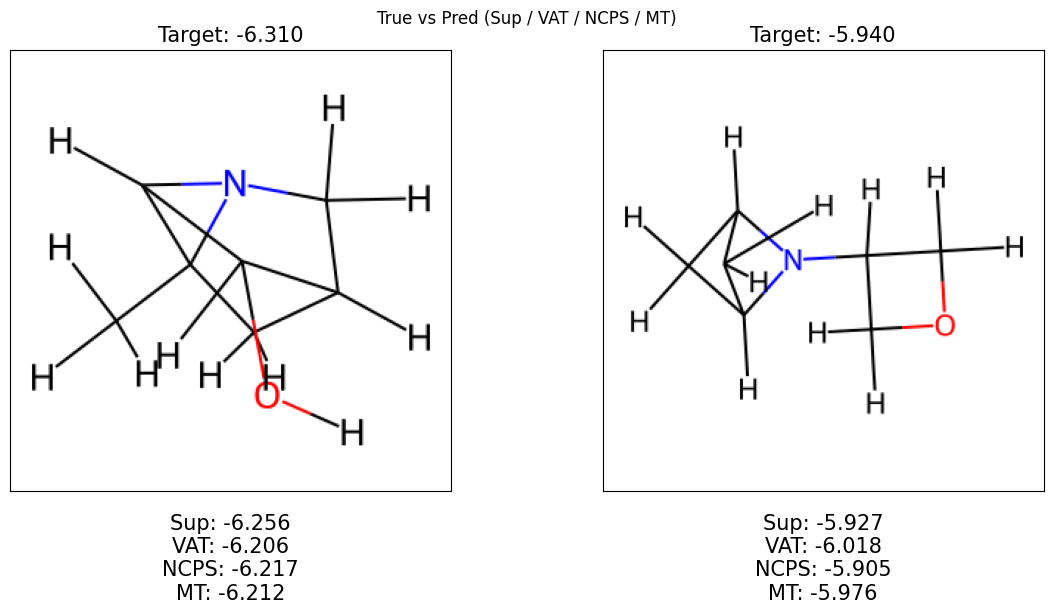

In [ ]:
models = {
    "Sup": model_sup,
    "VAT": model_vat,
    "NCPS": model_ncps,
    "MT": model_mt,
}

batch = next(iter(test_loader))
x, targets = batch
x_cpu, targets_cpu = x.cpu(), targets.cpu()

n = min(2, x_cpu.num_graphs)
fig, axes = plt.subplots(1, n, figsize=(12, 6))

for ax, i in zip(axes, range(n)):
    g = x_cpu.get_example(i)
    mol = pyg_to_rdkit(g)
    if mol is None:
        ax.axis("off")
        continue

    # Génère l’image de la molécule
    img = Draw.MolToImage(mol, size=(300, 300))
    arr = np.array(img)

    # Calcule les prédictions
    true_val = float(targets_cpu[i].view(-1)[0].item())
    lines = []
    for name, model in models.items():
        pred = predict_single(model, g, y_mean, y_std, device)
        lines.append(f"{name}: {pred:.3f}")

    # Affichage
    ax.imshow(arr)
    ax.set_title(f"Target: {true_val:.3f}", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(
        0.5, -0.05,
        "\n".join(lines),
        ha="center", va="top",
        transform=ax.transAxes,
        fontsize=12
    )

fig.suptitle("True vs Pred (Sup / VAT / NCPS / MT)", fontsize=15)
plt.tight_layout()
plt.show()
